In [192]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# EDA WITH RED WINE DATA

#####   Input variables (based on physicochemical tests):
#####   1 - fixed acidity
 #####  2 - volatile acidity
 #####  3 - citric acid
 #####  4 - residual sugar
 #####  5 - chlorides
 #####  6 - free sulfur dioxide
 #####  7 - total sulfur dioxide
 #####  8 - density
 #####  9 - pH
 #####  10 - sulphates
 #####  11 - alcohol
 #####  Output variable (based on sensory data):
 #####  12 - quality (score between 0 and 10)


In [193]:
df = pd.read_csv('../Stats_and_prob/winequality-red.csv', sep=';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [195]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [196]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [197]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [198]:
df1 = df.drop_duplicates()


##### Now we are going to draw a heatmap that will tell us the correlation between all the festures and that will help us determine the features that need to take for the Model training .

<Axes: >

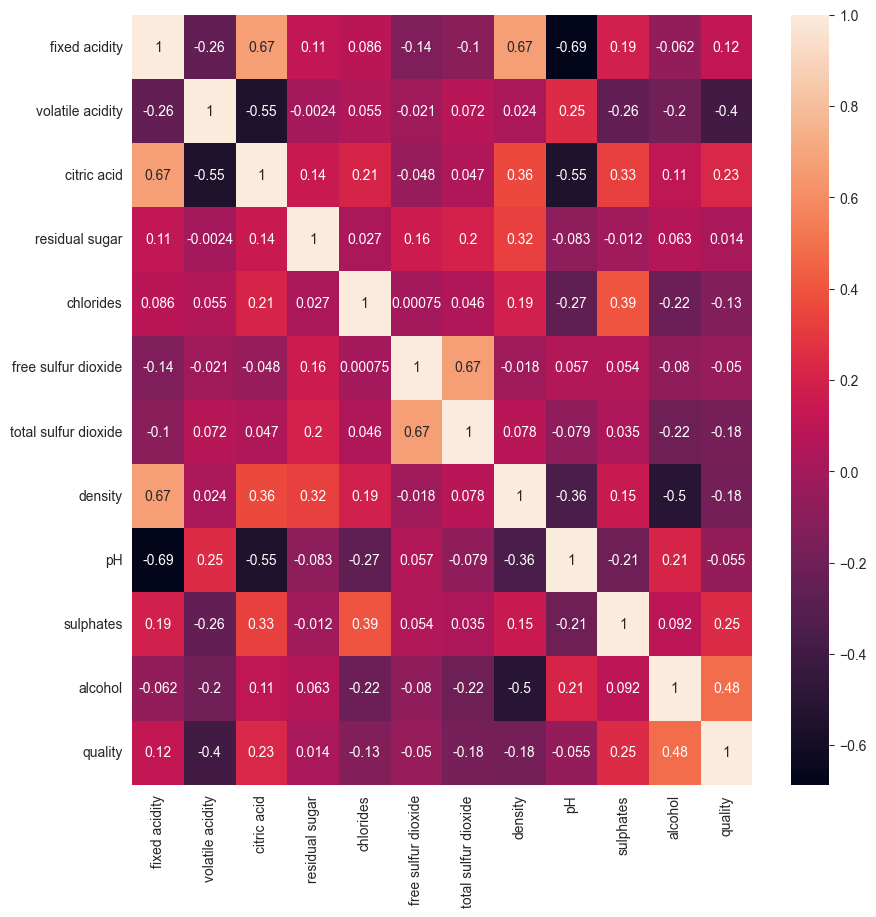

In [199]:
plt.figure(figsize=(10, 10))
sns.heatmap(df1.corr(), annot=True)

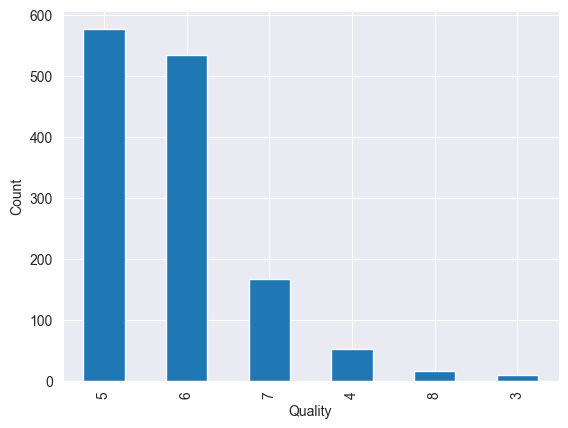

In [200]:
df1.quality.value_counts().plot(kind='bar')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

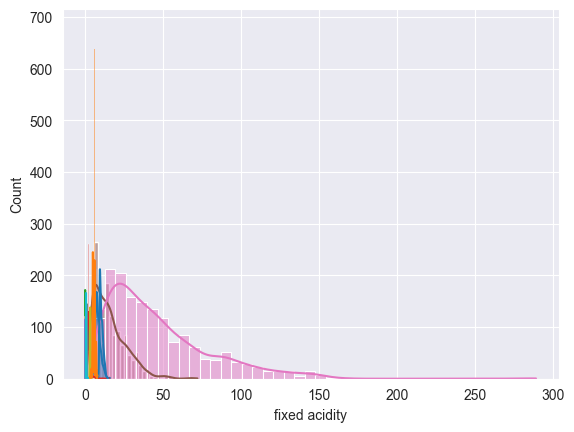

In [201]:
for col in df.columns:
    sns.histplot(df[col],kde=True)

<Axes: xlabel='alcohol', ylabel='Count'>

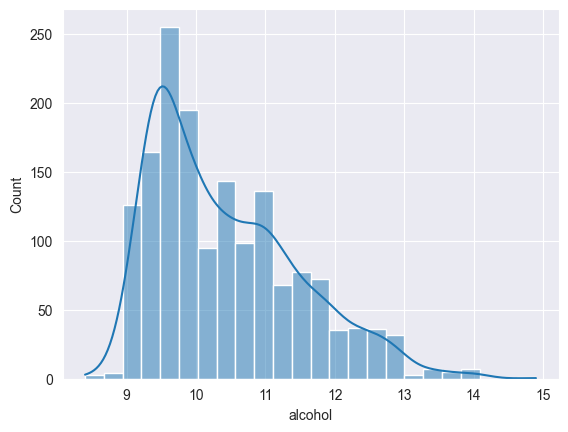

In [202]:
sns.histplot(df['alcohol'],kde=True)

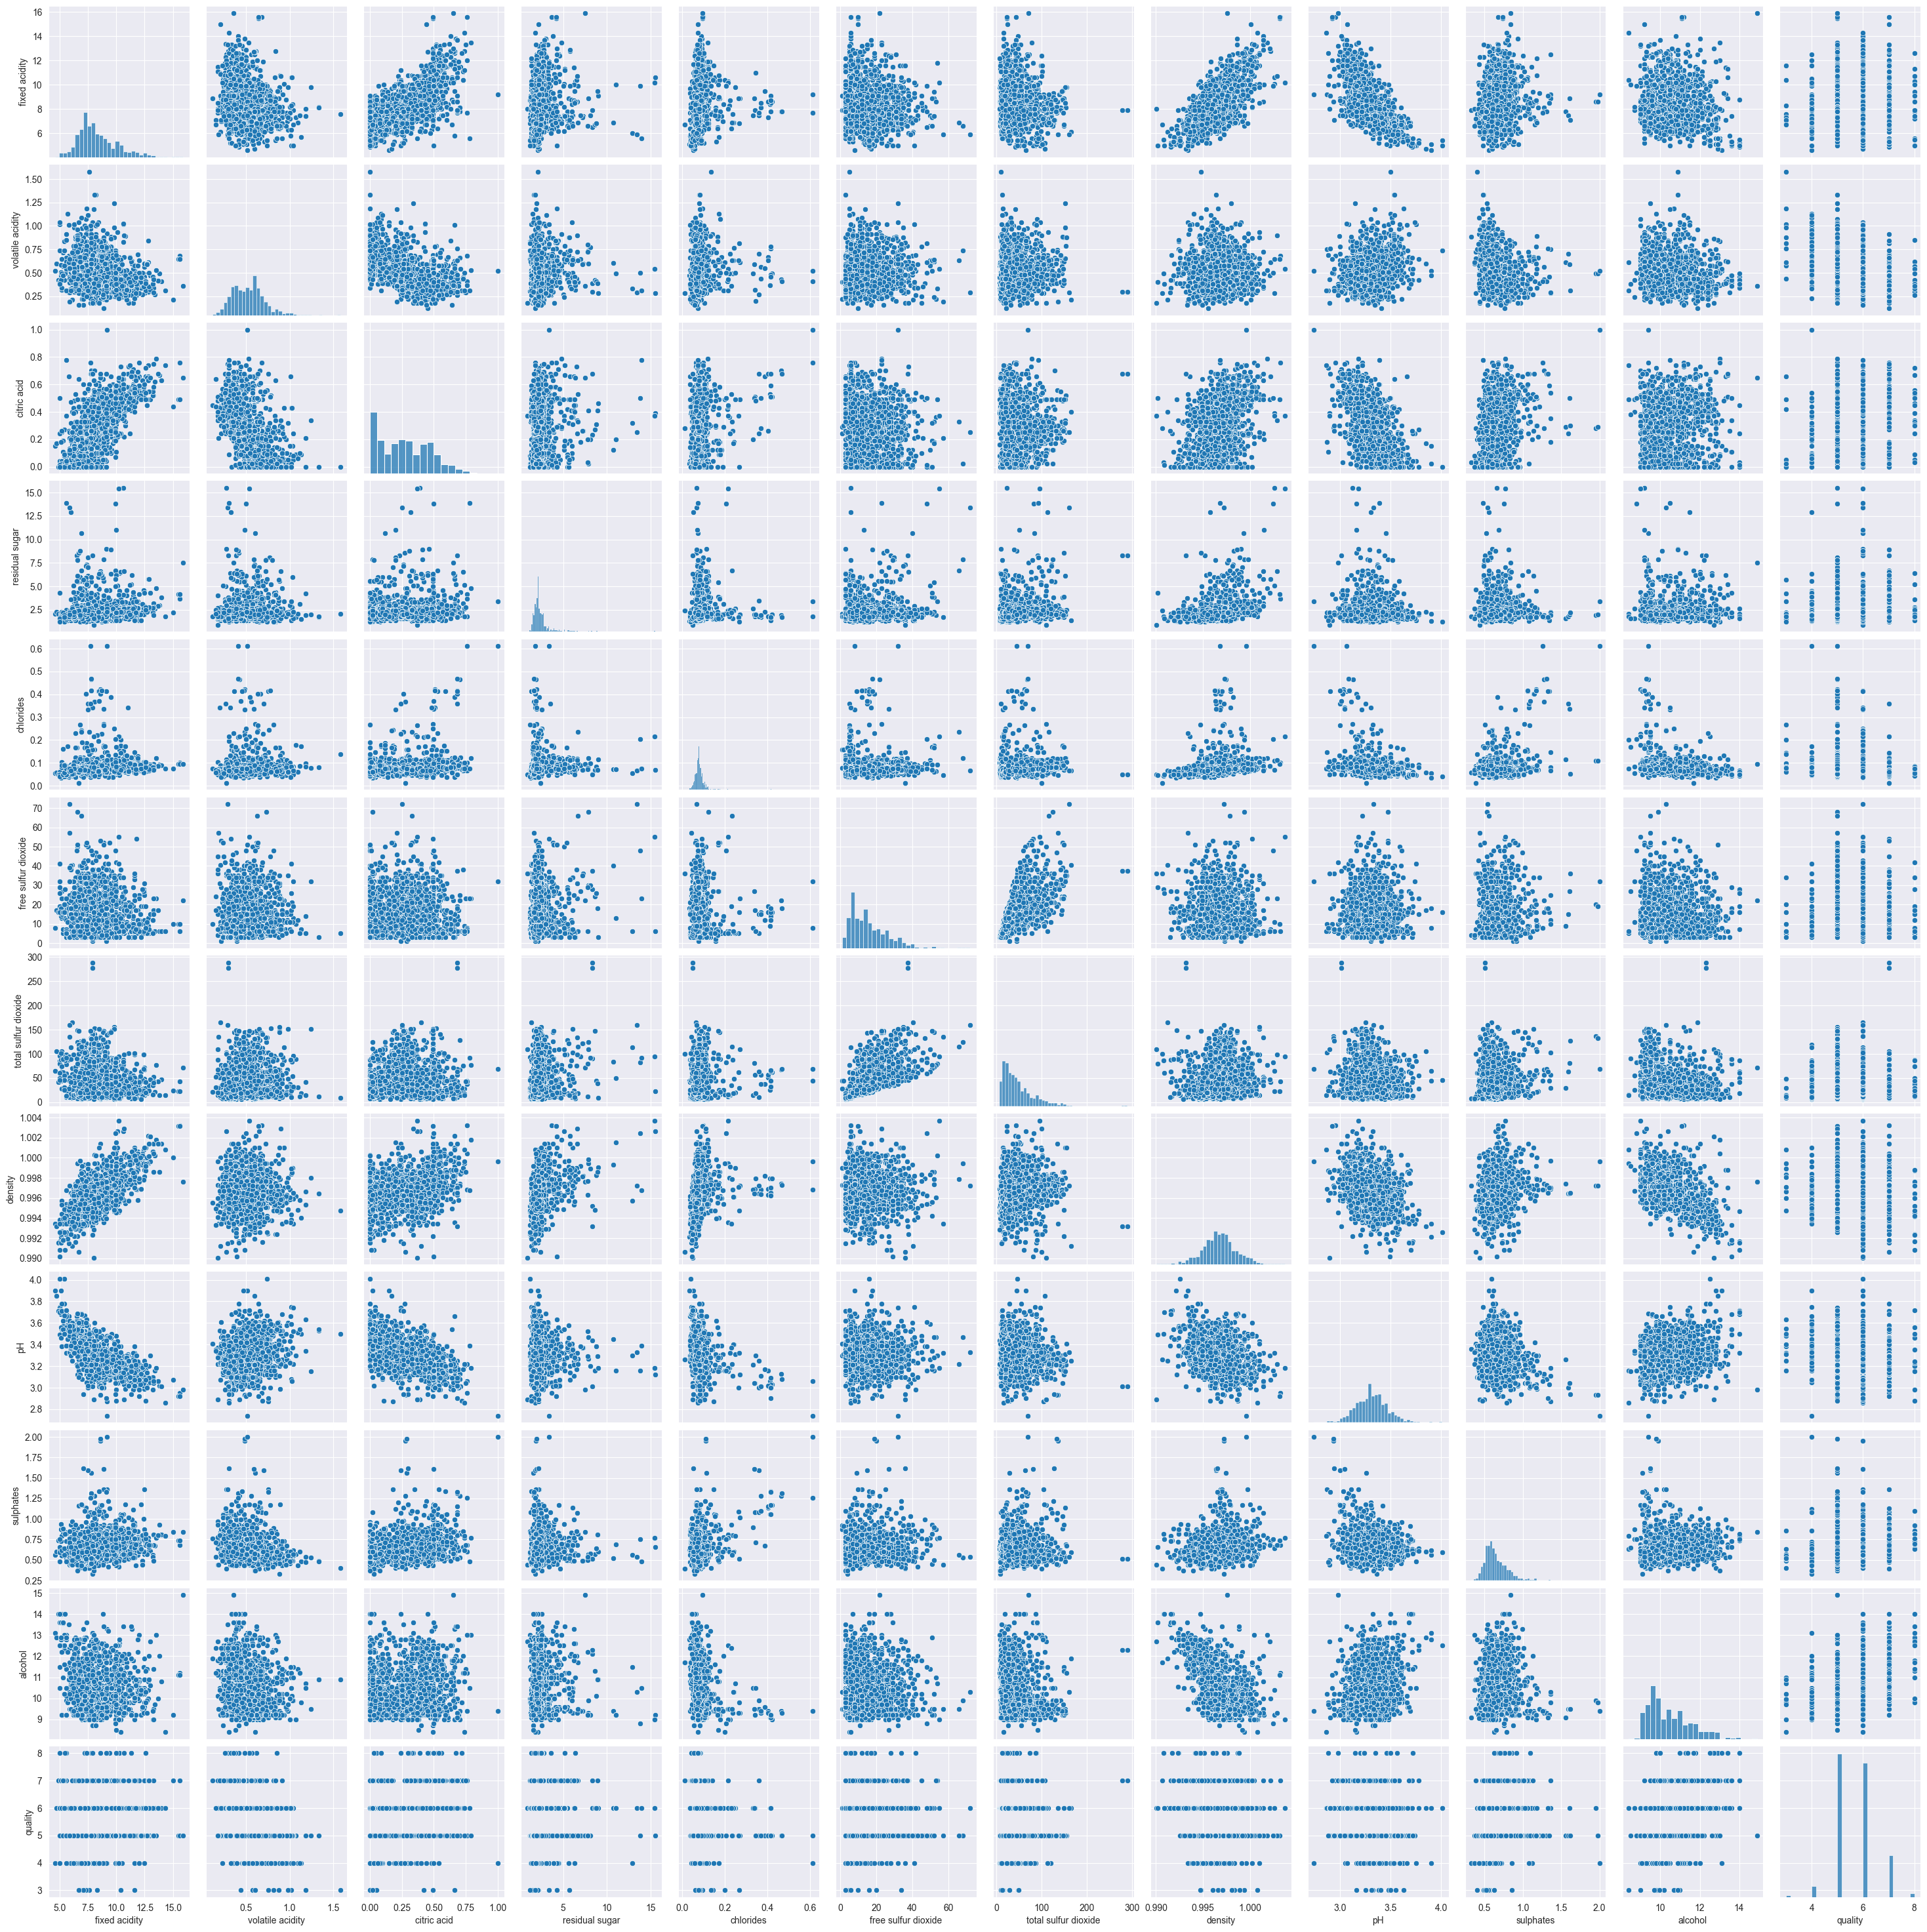

In [203]:
# univariate , bivariate , multivariate analysis
sns.pairplot(df)

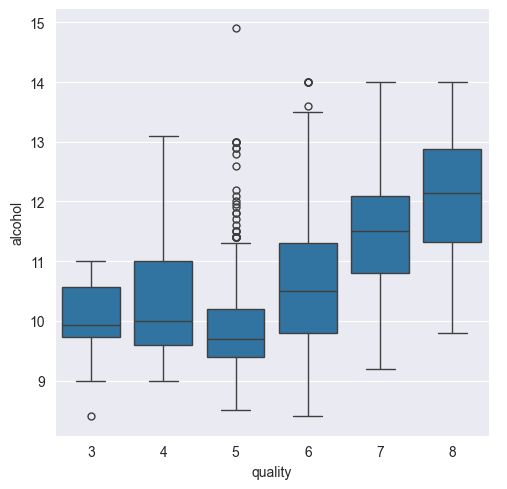

In [204]:
# categorical plot
sns.catplot(x='quality',y='alcohol',data=df,kind='box')

<Axes: xlabel='alcohol', ylabel='pH'>

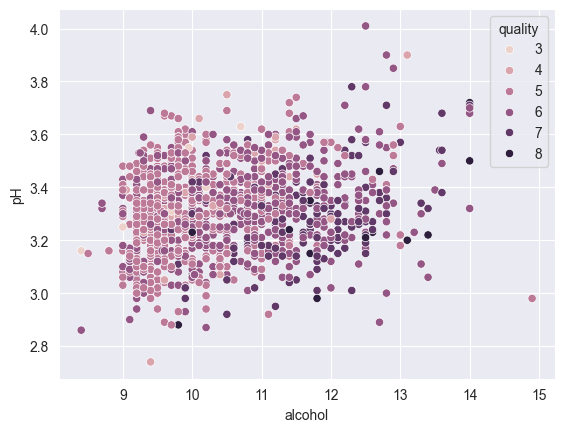

In [205]:
sns.scatterplot(x='alcohol',y='pH',hue='quality',data=df)

# FLIGHT PRICE PREDICTION

#### FEATURES

The various features of the cleaned dataset are explained below:
1) Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.
2) Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.
3) Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.
4) Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.
5) Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.
6) Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.
7) Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.
8) Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.
9) Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.
10)Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.
11) Price: Target variable stores information of the ticket price.



In [206]:
df = pd.read_csv('../Stats_and_prob/Clean_Dataset.csv')
df[df["stops"] == 'two_or_more']

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
175,175,Indigo,6E-282,Delhi,Morning,two_or_more,Evening,Mumbai,Economy,9.67,2,11678
312,312,GO_FIRST,G8-286,Delhi,Morning,two_or_more,Night,Mumbai,Economy,11.00,3,12045
496,496,GO_FIRST,G8-357,Delhi,Early_Morning,two_or_more,Evening,Mumbai,Economy,12.08,4,11295
611,611,GO_FIRST,G8-199,Delhi,Afternoon,two_or_more,Night,Mumbai,Economy,8.58,5,5954
628,628,Indigo,6E-282,Delhi,Morning,two_or_more,Evening,Mumbai,Economy,9.67,5,6953
...,...,...,...,...,...,...,...,...,...,...,...,...
295959,295959,Vistara,UK-838,Chennai,Night,two_or_more,Night,Kolkata,Business,23.67,2,71169
295985,295985,Vistara,UK-832,Chennai,Early_Morning,two_or_more,Night,Kolkata,Business,13.83,3,68963
295988,295988,Vistara,UK-832,Chennai,Early_Morning,two_or_more,Night,Kolkata,Business,13.83,3,71169
295993,295993,Vistara,UK-832,Chennai,Early_Morning,two_or_more,Morning,Kolkata,Business,26.67,3,77329


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [208]:
df["stops"].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [209]:
mapp = {
    'zero' : 0,
    'one' : 1,
    'two_or_more' : 2
}
df["stops"] = df["stops"].map(mapp)

In [210]:
df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [211]:
ohe = OneHotEncoder()
airlines_encoded = ohe.fit_transform(df[['airline']]).toarray()
df_airline = pd.DataFrame(airlines_encoded, columns=ohe.get_feature_names_out(['airline']))
df_airline

,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara
0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
300148,0.0,0.0,0.0,0.0,0.0,1.0
300149,0.0,0.0,0.0,0.0,0.0,1.0
300150,0.0,0.0,0.0,0.0,0.0,1.0
300151,0.0,0.0,0.0,0.0,0.0,1.0


In [212]:
pd.concat([df, df_airline], axis=1)
df.drop(columns=['airline'], inplace=True)

In [213]:
df

,Unnamed: 0,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SG-8709,Delhi,Evening,0,Night,Mumbai,Economy,2.17,1,5953
1,1,SG-8157,Delhi,Early_Morning,0,Morning,Mumbai,Economy,2.33,1,5953
2,2,I5-764,Delhi,Early_Morning,0,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,UK-995,Delhi,Morning,0,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,UK-963,Delhi,Morning,0,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,UK-822,Chennai,Morning,1,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,UK-826,Chennai,Afternoon,1,Night,Hyderabad,Business,10.42,49,77105
300150,300150,UK-832,Chennai,Early_Morning,1,Night,Hyderabad,Business,13.83,49,79099
300151,300151,UK-828,Chennai,Early_Morning,1,Evening,Hyderabad,Business,10.00,49,81585


In [214]:
df['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [215]:
df['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [216]:
df['arrival_time'].value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

In [217]:
departure_time_encoded = ohe.fit_transform(df[['departure_time']]).toarray()
df_departure = pd.DataFrame(departure_time_encoded,columns=ohe.get_feature_names_out(['departure_time']))
arrival_time_encoded = ohe.fit_transform(df[['arrival_time']]).toarray()
df_arrival = pd.DataFrame(arrival_time_encoded,columns=ohe.get_feature_names_out(['arrival_time']))
pd.concat([df,df_departure,df_arrival],axis=1)

,Unnamed: 0,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,...,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Afternoon,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night
0,0,SG-8709,Delhi,Evening,0,Night,Mumbai,Economy,2.17,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,SG-8157,Delhi,Early_Morning,0,Morning,Mumbai,Economy,2.33,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,I5-764,Delhi,Early_Morning,0,Early_Morning,Mumbai,Economy,2.17,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3,UK-995,Delhi,Morning,0,Afternoon,Mumbai,Economy,2.25,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,4,UK-963,Delhi,Morning,0,Morning,Mumbai,Economy,2.33,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,UK-822,Chennai,Morning,1,Evening,Hyderabad,Business,10.08,49,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
300149,300149,UK-826,Chennai,Afternoon,1,Night,Hyderabad,Business,10.42,49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
300150,300150,UK-832,Chennai,Early_Morning,1,Night,Hyderabad,Business,13.83,49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
300151,300151,UK-828,Chennai,Early_Morning,1,Evening,Hyderabad,Business,10.00,49,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [218]:
df['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [219]:
source_city_encoded = ohe.fit_transform(df[['source_city']]).toarray()
df_source = pd.DataFrame(source_city_encoded,columns=ohe.get_feature_names_out(['source_city']))
destination_city_encoded = ohe.fit_transform(df[['destination_city']]).toarray()
df_destination = pd.DataFrame(destination_city_encoded,columns=ohe.get_feature_names_out(['destination_city']))
pd.concat([df,df_source,df_destination],axis=1)

,Unnamed: 0,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,...,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0,SG-8709,Delhi,Evening,0,Night,Mumbai,Economy,2.17,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,SG-8157,Delhi,Early_Morning,0,Morning,Mumbai,Economy,2.33,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,I5-764,Delhi,Early_Morning,0,Early_Morning,Mumbai,Economy,2.17,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,UK-995,Delhi,Morning,0,Afternoon,Mumbai,Economy,2.25,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4,UK-963,Delhi,Morning,0,Morning,Mumbai,Economy,2.33,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,UK-822,Chennai,Morning,1,Evening,Hyderabad,Business,10.08,49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
300149,300149,UK-826,Chennai,Afternoon,1,Night,Hyderabad,Business,10.42,49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
300150,300150,UK-832,Chennai,Early_Morning,1,Night,Hyderabad,Business,13.83,49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
300151,300151,UK-828,Chennai,Early_Morning,1,Evening,Hyderabad,Business,10.00,49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [220]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [221]:
map_class = {
    'Economy' : 0,
    'Business' : 1
}
df['class'] = df['class'].map(map_class)

In [222]:
df

,Unnamed: 0,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SG-8709,Delhi,Evening,0,Night,Mumbai,0,2.17,1,5953
1,1,SG-8157,Delhi,Early_Morning,0,Morning,Mumbai,0,2.33,1,5953
2,2,I5-764,Delhi,Early_Morning,0,Early_Morning,Mumbai,0,2.17,1,5956
3,3,UK-995,Delhi,Morning,0,Afternoon,Mumbai,0,2.25,1,5955
4,4,UK-963,Delhi,Morning,0,Morning,Mumbai,0,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,UK-822,Chennai,Morning,1,Evening,Hyderabad,1,10.08,49,69265
300149,300149,UK-826,Chennai,Afternoon,1,Night,Hyderabad,1,10.42,49,77105
300150,300150,UK-832,Chennai,Early_Morning,1,Night,Hyderabad,1,13.83,49,79099
300151,300151,UK-828,Chennai,Early_Morning,1,Evening,Hyderabad,1,10.00,49,81585
